In [82]:
# Importer les bibliothèques necessaires
!pip install gdown
import gdown
import pandas as pd
import re
import gc
import os
import sys
import pandas as pd
import numpy as np
import tqdm
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC

In [83]:
np.random.seed(123)

In [84]:
# Charger les données
df = pd.read_csv('Fraud Detection Dataset.csv')  # changer le nom du fichier si nécessaire
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())


Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


# **Sommaire**

### Traitement des valeurs manquantes Na
1. 1ère méthode : moyenne
2. 2ème méthode : Interpolation Bayesienne

### Implémentation des modèles de classification
1. *RandomForest*
2. *Régression Logistique*
3. *SVM*
4. *LightGBM*

### Algorithme de génération de données synthétiques : SMOTE

0. Implémentation SMOTE

### Résultats **sans SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 


### Résultats **avec SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 



## **Traitement des valeurs manquantes Na**


### **1ère méthode : moyenne**

Implémentation fonction *missing_mean*

In [85]:

def missing_mean(df):
    """
    entrée : dataset df avec valeurs manquantes Na 
    sortie :df_mean dataset traité 
    """

    # Séparation des colonnes numériques et catégorielles
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Fraudulent')
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    # Création d'une copie de sécurité
    df_c = df.copy()
    
    # Remplacement des valeurs manquantes pour les variables numériques
    for col in numeric_cols:
        for fraud_value in [0, 1]:
            mean_value = df_c.loc[df_c['Fraudulent'] == fraud_value, col].mean()
            df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
    
    # Remplacement des valeurs manquantes pour les variables catégorielles
    for col in categorical_cols:
        for fraud_value in [0, 1]:
            mode_series = df_c.loc[df_c['Fraudulent'] == fraud_value, col].mode()
            if not mode_series.empty:
                mode_value = mode_series.iloc[0]
                df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mode_value
    
    # Vérification du remplissage
    print("Pourcentage de valeurs manquantes après traitement :")
    print((df_c.isnull().mean() * 100).round(3))

    return df_c


### **2ème méthode : Interpolation Bayesienne**

Implémentation fonction *missing_mean*

In [110]:

"""
Le code à rentrer ici prend en entrée "df" déjà définie juste avant et renvoie "df_interpolation"

"""

# 1) IMPUTATION BAYÉSIENNE POUR VARIABLES NUMÉRIQUES

def bayesian_impute_numeric(df, num_cols=None, alpha=1.0, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    df_out = df.copy()

    # Sélection automatique des colonnes numériques si non spécifiée
    if num_cols is None:
        num_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

    # Imputation colonne par colonne
    for col in num_cols:
        if df_out[col].isna().sum() == 0:
            continue  # Rien à imputer

        print(f"\n--- Imputation bayésienne de la colonne numérique : {col} ---")

        # Séparation Observé / Manquant
        mask_obs = df_out[col].notna()
        mask_miss = df_out[col].isna()

        y_obs = df_out.loc[mask_obs, col].values

        X_obs = df_out.loc[mask_obs, num_cols].copy()
        X_miss = df_out.loc[mask_miss, num_cols].copy()

        # Remplacer éventuels NaN des prédicteurs par leur moyenne
        X_obs = X_obs.fillna(X_obs.mean())
        X_miss = X_miss.fillna(X_obs.mean())

        # Matrices numpy
        Xo = X_obs.values
        Xm = X_miss.values

        # Ridge posterior : beta_hat = (X'X + αI)^(-1) X'y
        XtX = Xo.T @ Xo
        XtY = Xo.T @ y_obs

        Sigma_beta = np.linalg.inv(XtX + alpha * np.eye(Xo.shape[1]))
        beta_hat = Sigma_beta @ XtY

        # Variance résiduelle
        residuals = y_obs - Xo @ beta_hat
        sigma2 = residuals.var()

        # Variance prédictive (approx)
        pred_var = sigma2 + np.sum(Xm @ Sigma_beta * Xm, axis=1)

        # Moyenne prédictive
        pred_mean = Xm @ beta_hat

        # Tirage Monte-Carlo
        y_draws = np.random.normal(pred_mean, np.sqrt(pred_var))

        # Injection des valeurs imputées
        df_out.loc[mask_miss, col] = y_draws

    return df_out

# 2) IMPUTATION BAYÉSIENNE POUR VARIABLES CATÉGORIELLES

def categorical_dirichlet_impute(df, cat_cols=None, alpha0=1.0, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    df_out = df.copy()
    info = {}

    if cat_cols is None:
        cat_cols = df_out.select_dtypes(include=['object','category']).columns.tolist()

    for col in cat_cols:
        n_missing = df_out[col].isna().sum()
        if n_missing == 0:
            continue

        print(f"\n--- Imputation Dirichlet-Multinomial : {col} ---")

        observed = df_out[col].dropna().astype(str)
        counts = observed.value_counts().to_dict()

        categories = list(counts.keys())
        counts_arr = np.array(list(counts.values()), dtype=float)

        # Prior Dirichlet symétrique
        alpha = np.ones_like(counts_arr) * alpha0

        # Posterior = counts + prior
        posterior = counts_arr + alpha
        probs = posterior / posterior.sum()

        # Tirage pour chaque NA
        draws = np.random.choice(categories, size=n_missing, p=probs)

        # Injection
        missing_indices = df_out.index[df_out[col].isna()]
        df_out.loc[missing_indices, col] = draws

        info[col] = {
            "n_missing": n_missing,
            "categories": counts,
            "probs": dict(zip(categories, probs))
        }

    return df_out, info


def missing_interpolation(df):
    """
    entrée : dataset df avec valeurs manquantes Na
    sortie : dataset df_interpolation avec valeurs manquantes Na remplacées
    """
    # 1) Imputation numérique bayésienne
    df_num = bayesian_impute_numeric(df, alpha=1.0, random_state=123)

    # 2) Imputation catégorielle Dirichlet-Multinomial
    cat_cols = ["Device_Used", "Location", "Payment_Method"]

    df_traite, info = categorical_dirichlet_impute(df_num, cat_cols, alpha0=1.0, random_state=123)

    return df_traite


#df_final.to_csv("Fraud_Dataset_imputed_full.csv", index=False)



Preprocessing : 
Séparation des variables explicatives X de la variable expliquée y 

In [111]:
df_mean=missing_mean(df)
df_interpolation=missing_interpolation(df)

Pourcentage de valeurs manquantes après traitement :
Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64

--- Imputation bayésienne de la colonne numérique : Transaction_Amount ---

--- Imputation bayésienne de la colonne numérique : Time_of_Transaction ---

--- Imputation Dirichlet-Multinomial : Device_Used ---

--- Imputation Dirichlet-Multinomial : Location ---

--- Imputation Dirichlet-Multinomial : Payment_Method ---


/tmp/ipykernel_4770/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3002.9993194473086' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/tmp/ipykernel_4770/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9953598680140234' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/tmp/ipykernel_4770/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '59.98537842854197' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc

In [112]:
def separation(data):
    y=data['Fraudulent']
    X=data.drop(columns=['Fraudulent'])
    # Encodage des colonnes catégorielles
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y

In [113]:
# Encodage des colonnes catégorielles
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

### **Implémentation des modèles de classification**


In [114]:
X, y = separation(df_mean)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y)

### 1. *RandomForest*

In [115]:
def random_forest(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(A, b)
    
    #construction de y_pred
    y_pred=clf.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = clf.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba



### 2. *Régression Logistique*

Implémentation fonction *logistic*

In [116]:
def logistic(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • courbe ROC avec AUC
    • threshold intéressant et les métriques associées

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    #import LogisticRegression et on fit au modèle
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression()
    lr.fit(A,b)
    
    #construction de y_pred
    y_pred=lr.predict(T)
    
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = lr.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba


    

### 3. *SVM*

In [117]:
def svm(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    svc =SVC(kernel = 'rbf', C= 5, gamma= 'scale', probability=True )
    svc.fit(A,b)

    
    #construction de y_pred
    y_pred=svc.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = svc.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba



### 4. *LightGBM*

In [118]:
!pip install lightgbm
import lightgbm as lgb

def light_gbm(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    lgbm = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42)
    lgbm.fit(A, b)

    
    #construction de y_pred
    y_pred=lgbm.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = lgbm.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba



### **Algorithme de génération de données synthétiques : SMOTE**

0. Implémentation fonction *smote*

In [119]:
!pip install imblearn 

def smote(A,b,p):
    """
    (A,b) : dataset auquel est appliqué l'algorithme avec A les observations 
    des variables explicatives et b celles de la variable expliquée. 

    p : proportion de la classe minoritaire

    Remarques : On suppose ici que le dataset est traité, i.e que les valeurs manquantes
    ont été remplacées
    
    """
    P=A.reset_index(drop=True)
    q=b.reset_index(drop=True)


    try:
        #On exécute l'algorithme à partir du package imblearn
        from imblearn.over_sampling import SMOTE
        #On créer le modèle smote
        sm = SMOTE(sampling_strategy=p/(1-p), random_state=42) 
        #On applique smote au dataset (X,y) avec la méthode fit_resample
        X_res, y_res = sm.fit_resample(P, q) 
        #On vérifie que les classes ont bien été rééquilibrées
        print('Après SMOTE, comptes :', np.bincount(y_res.astype(int))) 


    #Si la première exécution a rencontré un problème
    except Exception as e:
        print('imblearn non disponible, SMOTE manuel.')
        # Version manuelle (comme avant)
        from sklearn.neighbors import NearestNeighbors
        X_np = P.values
        y_np = q.values
        minority_idx = np.where(y_np==1)[0]
        X_min = X_np[minority_idx]
        print(len(X_min))
        
        # SMOTE manuel
        n_majority = np.sum(y_np==0)
        target_ratio = p
        n_samples_needed = int(p*len(A) - len(X_min))
        print(n_samples_needed)
        
        
        neigh = NearestNeighbors(n_neighbors=5).fit(X_min)
        rng = np.random.RandomState(42)
        X_res,y_res=P,q
        for i in range(n_samples_needed):
            synthetic = []
            idx = rng.randint(0, X_min.shape[0])
            nn = neigh.kneighbors([X_min[idx]], return_distance=False)[0]
            nn_choice = rng.choice(nn[1:]) if len(nn) > 1 else nn[0]
            diff = X_min[nn_choice] - X_min[idx]
            gap = rng.rand()
            synthetic.append(X_min[idx] + gap * diff)
            #X_res = np.vstack([A, np.array(synthetic)])
            #y_res = np.hstack([b, np.ones(len(synthetic))])
            X_res=pd.concat([X_res, pd.DataFrame(synthetic,columns=P.columns)], axis = 0,ignore_index=True)
            y_res=pd.concat([y_res, pd.Series(1)], axis = 0, ignore_index=True)
        print('Après SMOTE manuel p, nouvelles formes :', X_res.shape, np.bincount(y_res.astype(int)))
    return X_res, y_res

def smote_bis(A,b,p):
    P=A.reset_index(drop=True)
    q=b.reset_index(drop=True)
    
    #On exécute l'algorithme à partir du package imblearn
    from imblearn.over_sampling import SMOTE
    #On créer le modèle smote
    sm = SMOTE(sampling_strategy=p/(1-p), random_state=42) 
    #On applique smote au dataset (X,y) avec la méthode fit_resample
    X_res, y_res = sm.fit_resample(P, q) 
    #On vérifie que les classes ont bien été rééquilibrées
    print('Après SMOTE, comptes :', np.bincount(y_res.astype(int)))
    return X_res, y_res




### **Métriques d'évaluation des modèles et courbes ROC (et AUC)**

1. Implémentation fonction résultat métriques

In [120]:
def metrics(y_pred,y_pred_proba,T,t,synthese):
    """
    entrée :

    • y_pred : valeurs prédites de la variable y
    • y_pred_proba : distribution de probabilité d'appartenance au deux classes des observations 
    X_test

    • (T,t) est le dataset de test

    • synthese est un booléen pour retourner ou non les valeurs des métriques

    sortie :

    • threshold intéressant, métriques associées + matrice de confusion

    On suppose avoir déjà séparé le dataset en train et test
    """
    

    #Tracé de la courbe ROC
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc, roc_auc_score

    """
    fpr : FP rate
    tpr : TP rate
    ths : threshold
    """  

    #La fonction roc_curve permet de tracer la courbe ROC 
    # à partir d'un vecteur de probabilités de la classe positive (ici (fraudulent=1))
    fpr, tpr, ths = roc_curve(t, y_pred_proba[:,1])
    auc_score = auc(fpr,tpr)
    #plt.plot(fpr,tpr,label="AUC Score:" + str(auc_score))
    #plt.xlabel('FALSE POSITIVE rate',fontsize='15')
    #plt.ylabel('TRUE POSITIVE rate',fontsize='15')
    #plt.legend(loc='best')





    #Recherche d'un seuil (threshold) idéal 
    """
    On souhaiterait maximiser le taux de détection d'une transaction frauduleuse
    tout en minimisant le taux de transaction non frauduleuses classées comme tel

    On va pour cela agir sur le seuil de classification (threshold)

    On va pour cela utiliser l'indice de Youden qui va nous permettre d'obtenir un 
    seuil de façon optimale selon l'indice de Youden. 
    """

    ###________ Au seuil optimal obtenu grâce à l'indice de Youden_________ ###
    """
    On va maximiser la quantité : recall + specificty - 1 
    On en tirera un seuil optimal noté threshold_y
    On s'intéressera aux métrques associées à ce seuil afin de les comparer à
    celles sans l'indice de Youden

    """
    youden= tpr - fpr
    index_max= np.where(youden==np.max(youden))
    threshold_index= np.max(index_max)
    threshold=ths[threshold_index]

    #On obtient de même de nouvelles valeurs prédites ajustées
    from sklearn.preprocessing import binarize
    from sklearn.metrics import confusion_matrix, f1_score
    y_pred_th= binarize(y_pred_proba, threshold=threshold)
    confusion_mat = confusion_matrix(t, y_pred_th[:,1],labels=[1,0])

    #Les métriques associées avec Youden
    recall=tpr[threshold_index]
    precision=(confusion_mat[0,0])/(confusion_mat[0,0] + confusion_mat[1,0])
    specificity=1-fpr[threshold_index]
    f_score=2*precision*recall/(precision+recall)


    ###________  Au seuil de 50% (par défaut)_________  ###

    #Mesure de l'accuracy du modèle au seuil de 50%
    from sklearn.metrics import accuracy_score
    accuracy=accuracy_score(t,y_pred)

    #Matrice de confusion au seuil de 50%
    confusion_matrix(t, y_pred,labels = [1,0])

    #Les métriques au seuil de 50%
    prec = precision_score(t, y_pred)
    rec = recall_score(t, y_pred)
    fscore = f1_score(t, y_pred)


    if synthese:
        return [recall,specificity,precision,f_score,youden[threshold_index],threshold]
    else:
        #Affichage métriques au seuil obtenu grâce à l'indice de Youden
        print("threshold avec Youden: " + str(threshold) )
        print("recall (sensitivity) avec Youden : " + str(recall) )
        print("precision avec Youden:" + str(precision))
        print("specificity avec Youden: " + str(specificity) )
        print("f1-score avec Youden : " + str(fscore))
        print("Indice de Youden: " + str(youden[threshold_index]))
        
        #Affichage métriques au seuil de 50%
        print("accuracy:" +str(accuracy))
        print("recall (sensitivity) au seuil de 50% : " + str(rec) )
        print("precision au seuil de 50%:" + str(prec))
        print("f1-score au seuil de 50% : " + str(f_score))





2. Implémentation fonction de tracé des courbes ROC

In [121]:
def roc(y_pred,y_pred_proba,T,t,synthese):
    """
    entrée :

    • y_pred : valeurs prédites de la variable y
    • y_pred_proba : distribution de probabilité d'appartenance au deux classes des observations 
    X_test

    • (T,t) est le dataset de test

    sortie :

    • threshold intéressant et les métriques associées

    On suppose avoir déjà séparé le dataset en train et test
    """

    #Tracé de la courbe ROC
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc, roc_auc_score

    """
    fpr : FP rate
    tpr : TP rate
    ths : threshold
    """  

    #La fonction roc_curve permet de tracer la courbe ROC 
    # à partir d'un vecteur de probabilités de la classe positive (ici (fraudulent=1))
    fpr, tpr, ths = roc_curve(t, y_pred_proba[:,1])
    auc_score = auc(fpr,tpr)
   
    #Mesure de l'accuracy du modèle
    from sklearn.metrics import accuracy_score
    accuracy=accuracy_score(t,y_pred)

    if synthese:
        return [auc_score]
    else:
        #Affichage AUC
        print("accuracy:" +str(accuracy))
        print("AUC: "+ str(auc_score))
        print(classification_report(t, y_pred))
        
        # Tracé effectif de la courbe ROC
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr)
        plt.plot([0,1],[0,1],'--')
        plt.xlabel('Taux de Faux Positifs')
        plt.ylabel('Taux de Vrais Positifs')
        plt.title('Courbe ROC (AUC = %.3f)' % auc_score)
        plt.show()



### **Résultats sans SMOTE**

1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

threshold avec Youden: 0.09
recall (sensitivity) avec Youden : 0.3286852589641434
precision avec Youden:0.0953360768175583
specificity avec Youden: 0.8204784491647763
f1-score avec Youden : 0.14074074074074075
Indice de Youden: 0.14916370812891966
accuracy:0.9545098039215686
recall (sensitivity) au seuil de 50% : 0.07569721115537849
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.14780182247025922
accuracy:0.9545098039215686
AUC: 0.6017273451050407
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       1.00      0.08      0.14       502

    accuracy                           0.95     10200
   macro avg       0.98      0.54      0.56     10200
weighted avg       0.96      0.95      0.94     10200



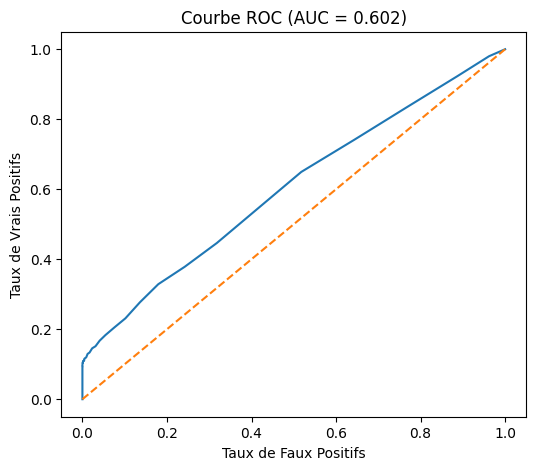

In [124]:
modele=random_forest
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

Régression Logistique

threshold avec Youden: 0.039331668139535876
recall (sensitivity) avec Youden : 0.6792828685258964
precision avec Youden:0.052011626128193364
specificity avec Youden: 0.3610022685089709
f1-score avec Youden : 0.0
Indice de Youden: 0.04028513703486725
accuracy:0.9507843137254902
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.09662483951767588
accuracy:0.9507843137254902
AUC: 0.5105001729522414
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWar

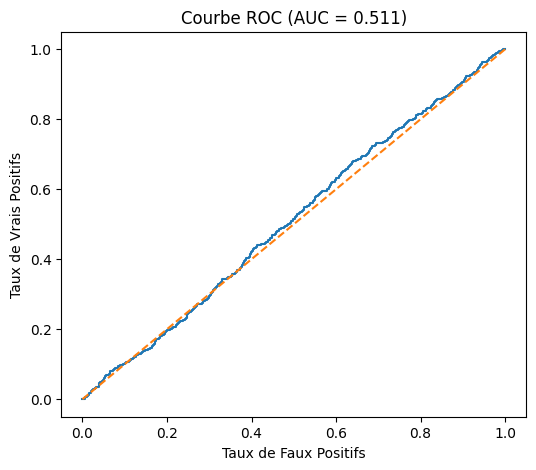

In [125]:
modele=logistic
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

SVM

threshold avec Youden: 0.05000053883048637
recall (sensitivity) avec Youden : 0.8904382470119522
precision avec Youden:0.050820419325433
specificity avec Youden: 0.14106001237368526
f1-score avec Youden : 0.0
Indice de Youden: 0.03149825938563744
accuracy:0.9507843137254902
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.09615304849757546
accuracy:0.9507843137254902
AUC: 0.49756161988466013
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/s

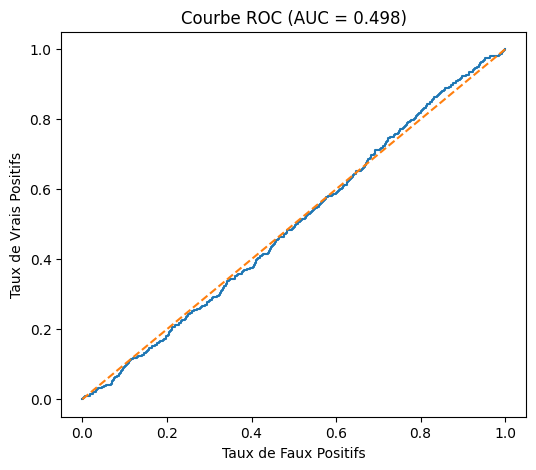

In [126]:
modele=svm
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

LightGBM

[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 953
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075
threshold avec Youden: 0.04247228367899819
recall (sensitivity) avec Youden : 0.599601593625498
precision avec Youden:0.06451612903225806
specificity avec Youden: 0.5514539080222727
f1-score avec Youden : 0.13553113553113552
Indice de Youden: 0.15105550164777065
accuracy:0.9537254901960784
recall (sensitivity) au seuil de 50% : 0.07370517928286853
precision au seuil de 50%:0.8409090909090909
f1-score au seuil de 50% : 0.11649733913884856
ac

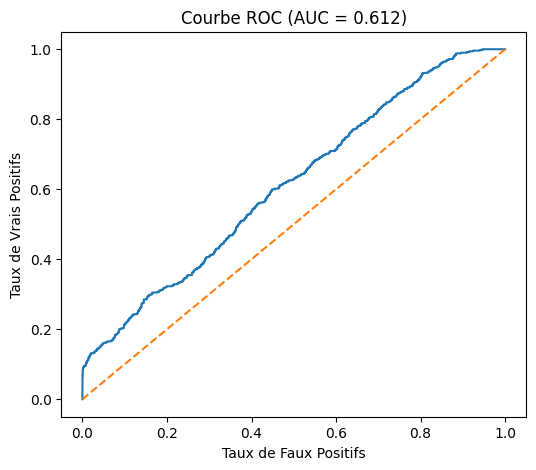

In [127]:
modele=light_gbm
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

### **Résultats avec SMOTE**

1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

In [128]:
X_s, y_s = smote(X,y,0.2)

Après SMOTE, comptes : [48490 12122]


In [129]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, 
random_state=42, stratify=y_s)

RandomForest

threshold avec Youden: 0.28
recall (sensitivity) avec Youden : 0.791340206185567
precision avec Youden:0.9156279961649089
specificity avec Youden: 0.979274077129305
f1-score avec Youden : 0.8074564630856021
Indice de Youden: 0.770614283314872
accuracy:0.9352470510599686
recall (sensitivity) au seuil de 50% : 0.6787628865979382
precision au seuil de 50%:0.9963680387409201
f1-score au seuil de 50% : 0.8489592791203578
accuracy:0.9352470510599686
AUC: 0.9251687562320214
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      9698
           1       1.00      0.68      0.81      2425

    accuracy                           0.94     12123
   macro avg       0.96      0.84      0.88     12123
weighted avg       0.94      0.94      0.93     12123



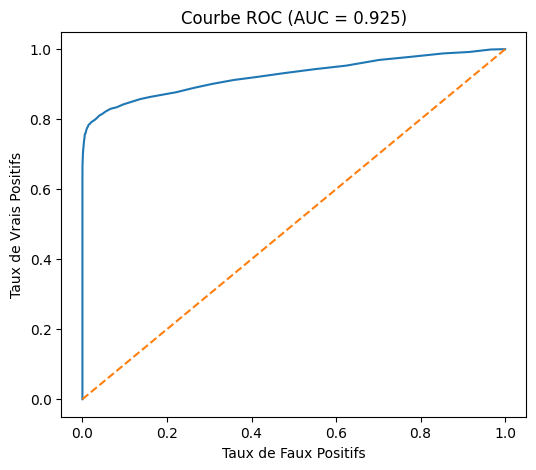

In [130]:
modele=random_forest
y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test_s, y_test_s)
metrics(y_pred, y_pred_proba,X_test_s, y_test_s,False)
roc(y_pred, y_pred_proba,X_test_s, y_test_s,False)

Régression Logistique

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


threshold avec Youden: 0.1788761108746977
recall (sensitivity) avec Youden : 0.7451546391752577
precision avec Youden:0.22757056451612903
specificity avec Youden: 0.36791090946586924
f1-score avec Youden : 0.0
Indice de Youden: 0.11306554864112695
accuracy:0.7999670048667822
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.34866015858416355
accuracy:0.7999670048667822
AUC: 0.5534925045657197
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      9698
           1       0.00      0.00      0.00      2425

    accuracy                           0.80     12123
   macro avg       0.40      0.50      0.44     12123
weighted avg       0.64      0.80      0.71     12123



/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


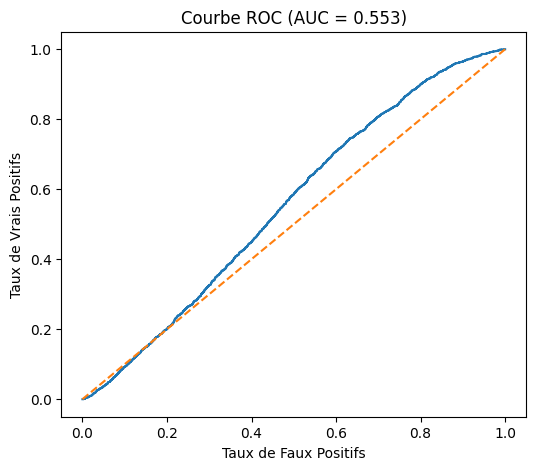

In [131]:
modele=logistic
y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test_s, y_test_s)
metrics(y_pred, y_pred_proba,X_test_s, y_test_s,False)
roc(y_pred, y_pred_proba,X_test_s, y_test_s,False)

SVM

threshold avec Youden: 0.2023955445188173
recall (sensitivity) avec Youden : 0.24371134020618557
precision avec Youden:0.24319868095630667
specificity avec Youden: 0.8106826149721592
f1-score avec Youden : 0.0
Indice de Youden: 0.05439395517834478
accuracy:0.7999670048667822
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.24345474069615947
accuracy:0.7999670048667822
AUC: 0.5328528573220539
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      9698
           1       0.00      0.00      0.00      2425

    accuracy                           0.80     12123
   macro avg       0.40      0.50      0.44     12123
weighted avg       0.64      0.80      0.71     12123



/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/s

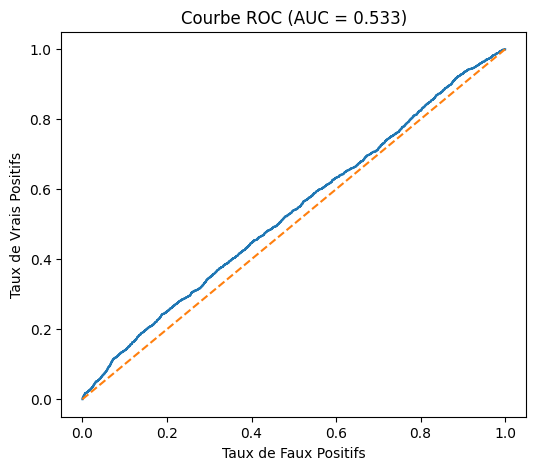

In [132]:
modele=svm
y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test_s, y_test_s)
metrics(y_pred, y_pred_proba,X_test_s, y_test_s,False)
roc(y_pred, y_pred_proba,X_test_s, y_test_s,False)

LightGBM

[LightGBM] [Info] Number of positive: 9697, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1806
[LightGBM] [Info] Number of data points in the train set: 48489, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199984 -> initscore=-1.386397
[LightGBM] [Info] Start training from score -1.386397
threshold avec Youden: 0.17234355894763864
recall (sensitivity) avec Youden : 0.8032989690721649
precision avec Youden:0.9843276036400405
specificity avec Youden: 0.9968034646318829
f1-score avec Youden : 0.8737819025522042
Indice de Youden: 0.8001024337040478
accuracy:0.9551266188237235
recall (sensitivity) au seuil de 50% : 0.7764948453608247
precision au seuil de 50%:0.9989389920424403
f1-score au seuil de 50% : 0.8846471195979669
accur

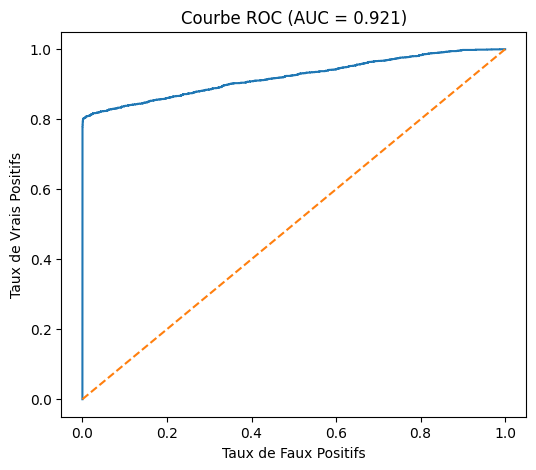

In [133]:
modele=light_gbm
y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test_s, y_test_s)
metrics(y_pred, y_pred_proba,X_test_s, y_test_s,False)
roc(y_pred, y_pred_proba,X_test_s, y_test_s,False)

### **Synthèse des résultats**

Création des dataset avec missing_mean et missing_interpolation

In [134]:
X, y = separation(df_mean)
P, q = separation(df_interpolation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y)
P_train, P_test, q_train, q_test = train_test_split(P, q, test_size=0.2, 
random_state=42, stratify=y)

Résultats **Sans SMOTE**

In [151]:
no_smote_col = pd.MultiIndex.from_tuples([('Sans SMOTE','Moyenne', 'recall'),('Sans SMOTE','Moyenne', 'specificity'),
                                       ('Sans SMOTE','Moyenne', 'precision'),('Sans SMOTE','Moyenne', 'f1-score'),
                                       ('Sans SMOTE','Moyenne', 'Indice de Youden'),('Sans SMOTE','Moyenne', 'seuil optimal'),
                                       ('Sans SMOTE','Interpolation Bayésienne', 'recall'),('Sans SMOTE','Interpolation Bayésienne', 'specificity'),
                                       ('Sans SMOTE','Interpolation Bayésienne', 'precision'),('Sans SMOTE','Interpolation Bayésienne', 'f1-score'),
                                       ('Sans SMOTE','Interpolation Bayésienne', 'Indice de Youden'),('Sans SMOTE','Interpolation Bayésienne', 'seuil optimal')])

smote_col = pd.MultiIndex.from_tuples([('Avec SMOTE','Interpolation Bayésienne', 'recall'),('Avec SMOTE','Interpolation Bayésienne', 'specificity'),
                                       ('Avec SMOTE','Interpolation Bayésienne', 'precision'),('Avec SMOTE','Interpolation Bayésienne', 'f1-score'),
                                       ('Avec SMOTE','Interpolation Bayésienne', 'Indice de Youden'),('Avec SMOTE','Interpolation Bayésienne', 'seuil optimal')])


liste=[random_forest,logistic,svm,light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
    q_pred, q_pred_proba = modele(P_train, q_train, P_test, q_test)
    L=metrics(y_pred, y_pred_proba,X_test, y_test,True) + metrics(q_pred, q_pred_proba,P_test, q_test,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','Régression Logistique','SVM','LightGBM'],columns=no_smote_col)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer 

[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 953
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075
[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [bi

In [152]:
df.stack(future_stack=True)

Sans SMOTE                         
                                          Moyenne Interpolation Bayésienne
RandomForest          recall             0.328685                 0.320717
                      specificity        0.820478                 0.737678
                      precision          0.095336                 0.060637
                      f1-score           0.147802                 0.101990
                      Indice de Youden   0.149164                 0.058395
                      seuil optimal      0.090000                 0.080000
Régression Logistique recall             0.679283                 0.776892
                      specificity        0.361002                 0.260260
                      precision          0.052012                 0.051435
                      f1-score           0.096625                 0.096482
                      Indice de Youden   0.040285                 0.037152
                      seuil optimal      0.039332                 0.032805
SVM                   recall             0.625498                 0.501992
                      specificity        0.403073                 0.530212
                      precision          0.051295                 0.052216
                      f1-score           0.094814                 0.094592
                      Indice de Youden   0.028571                 0.032204
                      seuil optimal      0.051367                 0.050154
LightGBM              recall             0.599602                 0.245020
                      specificity        0.551454                 0.805836
                      precision          0.064516                 0.060848
                      f1-score           0.116497                 0.097486
                      Indice de Youden   0.151056                 0.050856
                      seuil optimal      0.042472                 0.055310

Résultats **Avec SMOTE**


In [153]:
X_s, y_s = smote(X,y,0.2)
P_s, q_s =smote(P,q,0.2)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, 
random_state=42, stratify=y_s)
P_train_s, P_test_s, q_train_s, q_test_s = train_test_split(P_s, q_s, test_size=0.2, 
random_state=42, stratify=q_s)


Après SMOTE, comptes : [48490 12122]
Après SMOTE, comptes : [48490 12122]


In [154]:
smote_col = pd.MultiIndex.from_tuples([('SMOTE','Moyenne', 'recall'),('SMOTE','Moyenne', 'specificity'),
                                       ('SMOTE','Moyenne', 'precision'),('SMOTE','Moyenne', 'f1-score'),
                                       ('SMOTE','Moyenne', 'Indice de Youden'),('SMOTE','Moyenne', 'seuil optimal'),
                                       ('SMOTE','Interpolation Bayésienne', 'recall'),('SMOTE','Interpolation Bayésienne', 'specificity'),
                                       ('SMOTE','Interpolation Bayésienne', 'precision'),('SMOTE','Interpolation Bayésienne', 'f1-score'),
                                       ('SMOTE','Interpolation Bayésienne', 'Indice de Youden'),('SMOTE','Interpolation Bayésienne', 'seuil optimal')])



liste=[random_forest,logistic,svm,light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test_s, y_test_s)
    q_pred, q_pred_proba = modele(P_train_s, q_train_s, P_test_s, q_test_s)
    L=metrics(y_pred, y_pred_proba,X_test_s, y_test_s,True) + metrics(q_pred, q_pred_proba,P_test_s, q_test_s,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','Régression Logistique','SVM','LightGBM'],columns=smote_col)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer 

[LightGBM] [Info] Number of positive: 9697, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1806
[LightGBM] [Info] Number of data points in the train set: 48489, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199984 -> initscore=-1.386397
[LightGBM] [Info] Start training from score -1.386397
[LightGBM] [Info] Number of positive: 9697, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 48489, number of used features: 11
[LightGBM] [Info] [b

In [155]:
df.stack(future_stack=True)

SMOTE                         
                                         Moyenne Interpolation Bayésienne
RandomForest          recall            0.791340                 0.784742
                      specificity       0.979274                 0.865746
                      precision         0.915628                 0.606589
                      f1-score          0.848959                 0.684260
                      Indice de Youden  0.770614                 0.650488
                      seuil optimal     0.280000                 0.270000
Régression Logistique recall            0.745155                 0.846598
                      specificity       0.367911                 0.304186
                      precision         0.227571                 0.233182
                      f1-score          0.348660                 0.365651
                      Indice de Youden  0.113066                 0.150784
                      seuil optimal     0.178876                 0.161907
SVM                   recall            0.243711                 0.507216
                      specificity       0.810683                 0.570221
                      precision         0.243199                 0.227719
                      f1-score          0.243455                 0.314321
                      Indice de Youden  0.054394                 0.077437
                      seuil optimal     0.204081                 0.200592
LightGBM              recall            0.803299                 0.757938
                      specificity       0.996803                 0.995360
                      precision         0.984328                 0.976089
                      f1-score          0.884647                 0.853291
                      Indice de Youden  0.800102                 0.753298
                      seuil optimal     0.172344                 0.227725

AUC **sans SMOTE**

In [156]:
no_smote_col = pd.MultiIndex.from_tuples([('Sans SMOTE','Moyenne', 'AUC'),('Sans SMOTE','Interpolation Bayésienne', 'AUC')])

liste=[random_forest,logistic,svm,light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
    q_pred, q_pred_proba = modele(P_train, q_train, P_test, q_test)
    L=roc(y_pred, y_pred_proba,X_test, y_test,True) + roc(q_pred, q_pred_proba,P_test, q_test,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','Régression Logistique','SVM','LightGBM'],columns=no_smote_col)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer 

[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 953
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075
[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [bi

In [140]:
df.stack(future_stack=True)

Sans SMOTE                         
                             Moyenne Interpolation Bayésienne
RandomForest          AUC   0.601727                 0.527247
Régression Logistique AUC   0.510500                 0.505157
SVM                   AUC   0.502438                 0.508394
LightGBM              AUC   0.612198                 0.525040

AUC **avec SMOTE**

In [157]:
smote_col = pd.MultiIndex.from_tuples([('SMOTE','Moyenne', 'AUC'),('SMOTE','Interpolation Bayésienne', 'AUC')])

liste=[random_forest,logistic,svm,light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test_s, y_test_s)
    q_pred, q_pred_proba = modele(P_train_s, q_train_s, P_test_s, q_test_s)
    L=roc(y_pred, y_pred_proba,X_test_s, y_test_s,True) + roc(q_pred, q_pred_proba,P_test_s, q_test_s,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','Régression Logistique','SVM','LightGBM'],columns=smote_col)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer 

[LightGBM] [Info] Number of positive: 9697, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000430 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1806
[LightGBM] [Info] Number of data points in the train set: 48489, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199984 -> initscore=-1.386397
[LightGBM] [Info] Start training from score -1.386397
[LightGBM] [Info] Number of positive: 9697, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 48489, number of used features: 11
[LightGBM] [Info] [b

In [158]:
df.stack(future_stack=True)

SMOTE                         
                            Moyenne Interpolation Bayésienne
RandomForest          AUC  0.925169                 0.886233
Régression Logistique AUC  0.553493                 0.583368
SVM                   AUC  0.532853                 0.553186
LightGBM              AUC  0.921282                 0.897450

### **Conclusion sur le choix du modèle :**

Au vu de l'ensemble des performances, le modèle choisi est donc le lightGBM. 

Modifions les paramètres d'entrée du classificateur afin d'améliorer les performances du modèle. 

## **Fine-Tuning du modèle choisi : lightGBM**

Pour cela nous allons utiliser la fonction *RandomizedSearchCV* du package scikit-learn.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

lgbm = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42)
param_dist={'learning rate':[0.01,0.05,0.1,0.2],'num_leaves':[31,50,100,200,300],
             'max_depth':[-1,10,15,20],'min_child_samples':[10,20,30,50],
             'subsample':[0.6,0.8,1],'colsample_bytree':[0.6,0.8,1],
             'reg_alpha':[0,0.1,1,5],'reg_lambda':[0,0.1,1,5],
             'n_estimators':[500,1000,2000]}

search=RandomizedSearchCV(lgbm,param_distributions=param_dist,n_iter=50,cv=5,scoring='roc_auc',
                          random_state=42,n_jobs=-1,verbose=2)

search.fit(X_train_s, y_train_s)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid={'n_estimators':[500,1000,2000],'learning rate':[0.01,0.05,0.1],
           'num_leaves':[20,31,40],'max_depth':[-1,10,20]}

grid_search=GridSearchCV(estimator=lgbm,param_grid=param_grid,cv=3,scoring='roc_auc',n_jobs=-1,
verbose=1)

grid_search.fit(X_train_s,y_train_s)